In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
import os
import requests
import zipfile
from tqdm import tqdm # Optional: adds a nice progress bar

# Configuration
classes_to_download = ["walking", "boxing", "handclapping"]
base_url = "http://www.csc.kth.se/cvap/actions/"
output_dir = "./kth_videos/"

os.makedirs(output_dir, exist_ok=True)

def download_and_extract(action):
    zip_filename = f"{action}.zip"
    url = f"{base_url}{zip_filename}"
    zip_path = os.path.join(output_dir, zip_filename)

    print(f"--- Processing '{action}' ---")
    
    # Downloading using requests (works on Windows/Mac/Linux)
    print(f"Downloading {url}...")
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(zip_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
    else:
        print(f"Failed to download {action}. Status code: {response.status_code}")
        return

    # Extracting using zipfile (built-in Python library)
    print(f"Extracting {zip_filename}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(output_dir)

    # Clean up the zip file
    os.remove(zip_path)
    print(f"Done with {action}!\n")

if __name__ == "__main__":
    print("Starting downloads...")
    for action in classes_to_download:
        download_and_extract(action)
    print(f"All selected classes are ready in: {os.path.abspath(output_dir)}")

ModuleNotFoundError: No module named 'tqdm'

In [9]:
import cv2
import numpy as np
import pandas as pd
import os

def process_kth_dataset(video_dir=r"C:\Users\subhe\OneDrive\Desktop\VL-JEPA\codes\VL-JEPA-base-CCTV\kth_videos", output_csv="kth_cctv_features.csv"):
    print(f"Scanning directory {video_dir} for KTH videos...")

    if not os.path.exists(video_dir):
        print(f"Error: Directory {video_dir} not found. Please ensure your videos are extracted here.")
        return 0

    video_files = [f for f in os.listdir(video_dir) if f.endswith('.avi')]
    print(f"Found {len(video_files)} video files. Starting feature extraction...")

    dataset_records = []
    label_to_id = {}
    current_class_id = 0

    for filename in video_files:

        action_label = filename.split('_')[1]

        if action_label not in label_to_id:
            label_to_id[action_label] = current_class_id
            current_class_id += 1

        target_class_id = label_to_id[action_label]
        video_path = os.path.join(video_dir, filename)
        cap = cv2.VideoCapture(video_path)

        # Sample 5 frames per video
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames < 20:
            cap.release()
            continue

        frames_to_sample = np.linspace(10, total_frames - 10, 5, dtype=int)

        for frame_idx in frames_to_sample:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            if not ret: continue

            # Apply Simulated CCTV Occlusion Mask
            mask_x1, mask_x2 = 60, 100
            mask_y1, mask_y2 = 40, 80
            cv2.rectangle(frame, (mask_x1, mask_y1), (mask_x2, mask_y2), (0, 0, 0), -1)

            # Convert to HSV and extract 256-bin histogram
            hsv_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
            hist = cv2.calcHist([hsv_frame], [0, 1], None, [16, 16], [0, 180, 0, 256])
            cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

            features = hist.flatten().tolist()

            dataset_records.append({
                "video_file": filename,
                "target_class": target_class_id,
                "hsv_features": features
            })

        cap.release()

    # Save to CSV
    df = pd.DataFrame(dataset_records)
    df.to_csv(output_csv, index=False)

    print("\n--- Extraction Complete! ---")
    print(f"Total frames processed: {len(df)}")
    print(f"Classes found: {label_to_id}")
    print(f"Saved dataset to {output_csv}")

    return len(label_to_id)

num_found_classes = process_kth_dataset()

Scanning directory C:\Users\subhe\OneDrive\Desktop\VL-JEPA\codes\VL-JEPA-base-CCTV\kth_videos for KTH videos...
Found 299 video files. Starting feature extraction...

--- Extraction Complete! ---
Total frames processed: 1494
Classes found: {'boxing': 0, 'handclapping': 1, 'walking': 2}
Saved dataset to kth_cctv_features.csv


In [5]:
# import numpy as np
# import pandas as pd
# import ast
# import matplotlib.pyplot as plt

# class FinalNumPyJEPA:
#     def __init__(self, input_dim, target_classes, embed_dim=64, lr=0.01):
#         self.lr = lr

#         self.W_v = np.random.randn(embed_dim, input_dim) * np.sqrt(2. / input_dim)
#         self.b_v = np.zeros((embed_dim, 1))

#         self.W_y = np.random.randn(embed_dim, target_classes) * np.sqrt(2. / target_classes)
#         self.b_y = np.zeros((embed_dim, 1))

#         self.W_p = np.random.randn(embed_dim, embed_dim) * np.sqrt(2. / embed_dim)
#         self.b_p = np.zeros((embed_dim, 1))

#     def relu(self, Z): return np.maximum(0, Z)
#     def relu_deriv(self, Z): return Z > 0

#     def forward(self, X_v, Y):
#         # Encoders
#         Z_v = np.dot(self.W_v, X_v) + self.b_v
#         self.S_v = self.relu(Z_v)
#         self.S_y = np.dot(self.W_y, Y) + self.b_y

#         # Predictor
#         self.S_y_hat = np.dot(self.W_p, self.S_v) + self.b_p

#         # JEPA Embedding Loss
#         loss = 0.5 * np.sum((self.S_y_hat - self.S_y)**2)
#         return loss, Z_v

#     def backward(self, X_v, Y, Z_v):
#         d_S_y_hat = self.S_y_hat - self.S_y

#         # Predictor Gradients
#         d_W_p = np.dot(d_S_y_hat, self.S_v.T)
#         d_b_p = d_S_y_hat

#         # Visual Encoder Gradients
#         d_S_v = np.dot(self.W_p.T, d_S_y_hat)
#         d_Z_v = d_S_v * self.relu_deriv(Z_v)
#         d_W_v = np.dot(d_Z_v, X_v.T)
#         d_b_v = d_Z_v

#         # Target Encoder Gradients
#         d_S_y = -d_S_y_hat
#         d_W_y = np.dot(d_S_y, Y.T)
#         d_b_y = d_S_y

#         # Weight Updates
#         self.W_p -= self.lr * d_W_p; self.b_p -= self.lr * d_b_p
#         self.W_v -= self.lr * d_W_v; self.b_v -= self.lr * d_b_v
#         self.W_y -= self.lr * d_W_y; self.b_y -= self.lr * d_b_y

# def run_training_and_plot(csv_path=r"C:\Users\Ayushman\VL-JEPA-base-CCTV\kth_motion_features2.csv", num_classes=3, epochs=40):
#     print(f"Loading dataset from {csv_path}...")
#     try:
#         df = pd.read_csv(csv_path)
#     except FileNotFoundError:
#         print("Error: CSV not found. Did you run the extraction cell first?")
#         return

#     df['hsv_features'] = df['hsv_features'].apply(ast.literal_eval)


#     model = FinalNumPyJEPA(input_dim=256, target_classes=num_classes, embed_dim=64, lr=0.005)
#     loss_history = []

#     print("Starting Training Simulation...")
#     for epoch in range(epochs):
#         df_shuffled = df.sample(frac=1).reset_index(drop=True)
#         epoch_loss = 0

#         for index, row in df_shuffled.iterrows():
#             X_v = np.array(row['hsv_features']).reshape(256, 1)
#             Y = np.zeros((num_classes, 1))
#             Y[int(row['target_class']), 0] = 1.0

#             loss, Z_v = model.forward(X_v, Y)
#             model.backward(X_v, Y, Z_v)
#             epoch_loss += loss

#         avg_loss = epoch_loss / len(df)
#         loss_history.append(avg_loss)
#         if (epoch+1) % 5 == 0 or epoch == 0:
#             print(f"Epoch {epoch+1}/{epochs} | Average JEPA Latent Loss: {avg_loss:.4f}")
   


#     plt.figure(figsize=(9, 5))
#     plt.plot(loss_history, marker='o', linestyle='-', color='#1f77b4', linewidth=2)
#     plt.title('VL-JEPA: NumPy Embedding-Space Training Loss', fontsize=14, fontweight='bold')
#     plt.xlabel('Training Epochs', fontsize=12)
#     plt.ylabel('L2 Latent Distance', fontsize=12)
#     plt.grid(True, linestyle='--', alpha=0.7)
#     plt.tight_layout()
#     plt.show()


# try:
#     run_training_and_plot(num_classes=num_found_classes, epochs=40)
# except NameError:

#     print("Please manually enter the number of classes found:")
#     manual_classes = int(input("> "))
#     run_training_and_plot(num_classes=manual_classes, epochs=40)


In [ ]:
# 1. VISION TRANSFORMER (X-Encoder)
# ==========================================
class PatchEmbedding:
    def __init__(self, img_size=224, patch_size=16, in_ch=3, embed_dim=256):
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.num_patches = (img_size // patch_size) ** 2
        patch_dim = patch_size * patch_size * in_ch
        self.W = np.random.randn(patch_dim, embed_dim) / np.sqrt(patch_dim)

    def forward(self, x):
        B, H, W, C = x.shape
        p = self.patch_size
        patches = []
        for i in range(0, H, p):
            for j in range(0, W, p):
                patch = x[:, i:i+p, j:j+p, :].reshape(B, -1)
                patches.append(patch)
        patches = np.stack(patches, axis=1)   # (B, N, patch_dim)
        return patches @ self.W               # (B, N, embed_dim)

class LayerNorm:
    def __init__(self, dim, eps=1e-5):
        self.gamma = np.ones((1, 1, dim))
        self.beta = np.zeros((1, 1, dim))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(axis=-1, keepdims=True)
        var = x.var(axis=-1, keepdims=True)
        x_norm = (x - mean) / np.sqrt(var + self.eps)
        return self.gamma * x_norm + self.beta

class MLP:
    def __init__(self, dim, hidden_dim):
        self.W1 = np.random.randn(dim, hidden_dim) / np.sqrt(dim)
        self.W2 = np.random.randn(hidden_dim, dim) / np.sqrt(hidden_dim)

    def gelu(self, x):
        return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * np.power(x, 3))))

    def forward(self, x):
        return self.gelu(x @ self.W1) @ self.W2

class MultiHeadSelfAttention:
    def __init__(self, dim, heads=8):
        self.dim = dim
        self.heads = heads
        self.head_dim = dim // heads
        self.Wq = np.random.randn(dim, dim) / np.sqrt(dim)
        self.Wk = np.random.randn(dim, dim) / np.sqrt(dim)
        self.Wv = np.random.randn(dim, dim) / np.sqrt(dim)
        self.Wo = np.random.randn(dim, dim) / np.sqrt(dim)

    def forward(self, x):
        B, N, D = x.shape
        Q = x @ self.Wq
        K = x @ self.Wk
        V = x @ self.Wv

        Q = Q.reshape(B, N, self.heads, self.head_dim).transpose(0,2,1,3)
        K = K.reshape(B, N, self.heads, self.head_dim).transpose(0,2,1,3)
        V = V.reshape(B, N, self.heads, self.head_dim).transpose(0,2,1,3)

        scores = Q @ K.transpose(0,1,3,2) / np.sqrt(self.head_dim)
        
        # Stability adjustment for Softmax
        scores = scores - np.max(scores, axis=-1, keepdims=True)
        attn = np.exp(scores)
        attn = attn / attn.sum(axis=-1, keepdims=True)

        out = attn @ V
        out = out.transpose(0,2,1,3).reshape(B, N, D)
        return out @ self.Wo

class TransformerBlock:
    def __init__(self, dim, heads):
        self.norm1 = LayerNorm(dim)
        self.norm2 = LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, heads)
        self.mlp = MLP(dim, dim*4)

    def forward(self, x):
        x = x + self.attn.forward(self.norm1.forward(x))
        x = x + self.mlp.forward(self.norm2.forward(x))
        return x

class NumPyViT:
    def __init__(self, img_size=224, patch_size=16, embed_dim=256, depth=4, heads=4):
        self.patch_embed = PatchEmbedding(img_size, patch_size, 3, embed_dim)
        self.pos_embed = np.random.randn(1, self.patch_embed.num_patches, embed_dim)
        self.blocks = [TransformerBlock(embed_dim, heads) for _ in range(depth)]
        self.norm = LayerNorm(embed_dim)

    def forward(self, x):
        x = self.patch_embed.forward(x)
        x = x + self.pos_embed
        for blk in self.blocks:
            x = blk.forward(x)
        return self.norm.forward(x)

Loading features from C:\Users\subhe\OneDrive\Desktop\VL-JEPA\codes\VL-JEPA-base-CCTV\kth_spatial_motion3.csv...
Starting LLaMA-Predictor Training on 239 samples...
Holding back 60 samples for hidden testing...
Epoch 1/400 | InfoNCE Loss: 1.3964
Epoch 5/400 | InfoNCE Loss: 1.3096
Epoch 10/400 | InfoNCE Loss: 1.2694
Epoch 15/400 | InfoNCE Loss: 1.2156
Epoch 20/400 | InfoNCE Loss: 1.2235
Epoch 25/400 | InfoNCE Loss: 1.2106
Epoch 30/400 | InfoNCE Loss: 1.1082
Epoch 35/400 | InfoNCE Loss: 1.1178
Epoch 40/400 | InfoNCE Loss: 1.1259
Epoch 45/400 | InfoNCE Loss: 1.1217
Epoch 50/400 | InfoNCE Loss: 1.0956
Epoch 55/400 | InfoNCE Loss: 1.0328
Epoch 60/400 | InfoNCE Loss: 0.9994
Epoch 65/400 | InfoNCE Loss: 1.0745
Epoch 70/400 | InfoNCE Loss: 0.9597
Epoch 75/400 | InfoNCE Loss: 0.9809
Epoch 80/400 | InfoNCE Loss: 0.9183
Epoch 85/400 | InfoNCE Loss: 0.9367
Epoch 90/400 | InfoNCE Loss: 0.9118
Epoch 95/400 | InfoNCE Loss: 0.9034
Epoch 100/400 | InfoNCE Loss: 0.9312
Epoch 105/400 | InfoNCE Loss: 0.90

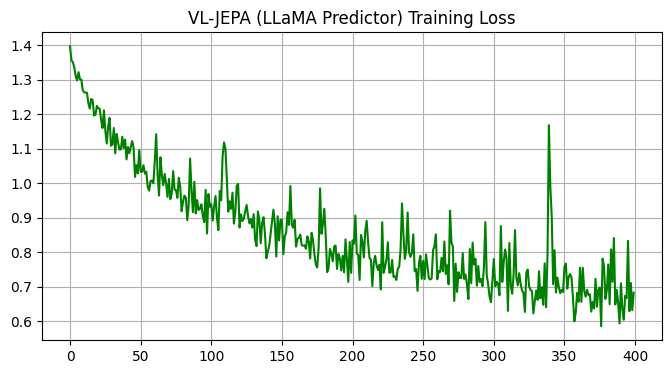

In [ ]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt

# ==========================================
# 1. TEXT ENCODER & INFONCE LOSS
# ==========================================
vocab = ["a", "person", "walking", "boxing", "clapping", "action","describe"]

class SimpleTextEncoder:
    def __init__(self, vocab, embed_dim=64): 
        np.random.seed(42)
        self.embed_dim = embed_dim
        self.word_to_idx = {w:i for i,w in enumerate(vocab)}
        self.embeddings = np.random.randn(len(vocab), embed_dim) * 1.0 

    def encode(self, words):
        idxs = [self.word_to_idx[w] for w in words]
        sentence = np.mean(self.embeddings[idxs], axis=0)
        return sentence.reshape(-1, 1)

class InfoNCELoss:
    def __init__(self, temperature=0.1):
        self.tau = temperature

    def forward(self, S_y_hat, S_y):
        self.batch_size = S_y_hat.shape[1]
        self.norm_P = np.linalg.norm(S_y_hat, axis=0, keepdims=True) + 1e-8
        self.norm_T = np.linalg.norm(S_y, axis=0, keepdims=True) + 1e-8
        self.P = S_y_hat / self.norm_P
        self.T = S_y / self.norm_T
        self.logits = np.dot(self.P.T, self.T) / self.tau
        exp_logits = np.exp(self.logits - np.max(self.logits, axis=1, keepdims=True))
        self.softmax = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
        target_probs = np.diag(self.softmax)
        return -np.mean(np.log(target_probs + 1e-8))

    def backward(self, S_y_hat):
        d_logits = self.softmax.copy()
        np.fill_diagonal(d_logits, np.diag(d_logits) - 1)
        d_logits /= self.batch_size
        d_P = np.dot(self.T, d_logits.T) / self.tau
        dot_dP_P = np.sum(d_P * self.P, axis=0, keepdims=True)
        return (d_P - self.P * dot_dP_P) / self.norm_P

# ==========================================
# 2. YOUR LLaMA-STYLE TRANSFORMER COMPONENTS
# ==========================================
def stable_softmax(x, axis=-1):
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / e_x.sum(axis=axis, keepdims=True)

def sigmoid(x):
    x_clipped = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x_clipped))

def silu(x): return x * sigmoid(x)
def silu_derivative(x):
    s = sigmoid(x)
    return s + x * s * (1.0 - s)

class NumPyRMSNorm:
    def __init__(self, embed_dim, learning_rate=0.001, eps=1e-6):
        self.eps, self.lr = eps, learning_rate
        self.gamma = np.ones((embed_dim,))
        self.cache = {} # Dict for batch caching

    def forward(self, x, b_idx=0):
        rms = np.sqrt(np.mean(x**2, axis=-1, keepdims=True) + self.eps)
        x_norm = x / rms
        out = self.gamma * x_norm
        self.cache[b_idx] = {'x': x, 'x_norm': x_norm, 'rms': rms}
        return out

    def backward(self, d_out, b_idx=0):
        c = self.cache[b_idx]
        x, x_norm, rms, N = c['x'], c['x_norm'], c['rms'], c['x'].shape[-1]
        
        d_gamma = np.sum(d_out * x_norm, axis=0)
        d_x_norm = d_out * self.gamma
        d_rms = np.sum(d_x_norm * x * (-1.0 / (rms**2)), axis=-1, keepdims=True)
        d_x = (d_x_norm / rms) + (d_rms * x / (N * rms))
        
        self.gamma -= self.lr * d_gamma
        return d_x

class NumPyMultiHeadAttention:
    def __init__(self, embed_dim, num_heads, learning_rate=0.001):
        self.embed_dim, self.num_heads, self.lr = embed_dim, num_heads, learning_rate
        self.head_dim = embed_dim // num_heads
        
        self.W_q = np.random.randn(embed_dim, embed_dim) * np.sqrt(2. / embed_dim)
        self.W_k = np.random.randn(embed_dim, embed_dim) * np.sqrt(2. / embed_dim)
        self.W_v = np.random.randn(embed_dim, embed_dim) * np.sqrt(2. / embed_dim)
        self.W_o = np.random.randn(embed_dim, embed_dim) * np.sqrt(2. / embed_dim)
        self.cache = {}

    def forward(self, x, b_idx=0):
        seq_len = x.shape[0]
        Q_full, K_full, V_full = np.dot(x, self.W_q), np.dot(x, self.W_k), np.dot(x, self.W_v)
        
        Q = Q_full.reshape(seq_len, self.num_heads, self.head_dim).transpose(1, 0, 2)
        K = K_full.reshape(seq_len, self.num_heads, self.head_dim).transpose(1, 0, 2)
        V = V_full.reshape(seq_len, self.num_heads, self.head_dim).transpose(1, 0, 2)
        
        scores = np.matmul(Q, K.transpose(0, 2, 1)) / np.sqrt(self.head_dim)
        attention_weights = stable_softmax(scores, axis=-1)
        
        context_output = np.matmul(attention_weights, V)
        context_output_flat = context_output.transpose(1, 0, 2).reshape(seq_len, self.embed_dim)
        final_output = np.dot(context_output_flat, self.W_o)
        
        self.cache[b_idx] = {'x': x, 'Q': Q, 'K': K, 'V': V, 'attention_weights': attention_weights, 'context_output_flat': context_output_flat}
        return final_output

    def backward(self, d_out, b_idx=0):
        c = self.cache[b_idx]
        x, Q, K, V, aw, co_flat = c['x'], c['Q'], c['K'], c['V'], c['attention_weights'], c['context_output_flat']
        seq_len = x.shape[0]

        d_W_o = np.dot(co_flat.T, d_out)
        d_context_flat = np.dot(d_out, self.W_o.T)
        d_context = d_context_flat.reshape(seq_len, self.num_heads, self.head_dim).transpose(1, 0, 2)

        d_V = np.matmul(aw.transpose(0, 2, 1), d_context)
        d_aw = np.matmul(d_context, V.transpose(0, 2, 1))
        
        d_scores = aw * (d_aw - np.sum(d_aw * aw, axis=-1, keepdims=True)) / np.sqrt(self.head_dim)

        d_Q = np.matmul(d_scores, K)
        d_K = np.matmul(d_scores.transpose(0, 2, 1), Q)

        d_Q_flat = d_Q.transpose(1, 0, 2).reshape(seq_len, self.embed_dim)
        d_K_flat = d_K.transpose(1, 0, 2).reshape(seq_len, self.embed_dim)
        d_V_flat = d_V.transpose(1, 0, 2).reshape(seq_len, self.embed_dim)

        d_W_q = np.dot(x.T, d_Q_flat)
        d_W_k = np.dot(x.T, d_K_flat)
        d_W_v = np.dot(x.T, d_V_flat)
        d_x = np.dot(d_Q_flat, self.W_q.T) + np.dot(d_K_flat, self.W_k.T) + np.dot(d_V_flat, self.W_v.T)

        self.W_q -= self.lr * d_W_q
        self.W_k -= self.lr * d_W_k
        self.W_v -= self.lr * d_W_v
        self.W_o -= self.lr * d_W_o
        return d_x

class NumPySwiGLUFFN:
    def __init__(self, embed_dim, hidden_dim=None, learning_rate=0.001):
        self.embed_dim, self.lr = embed_dim, learning_rate
        self.hidden_dim = hidden_dim if hidden_dim else embed_dim * 4
        
        self.W_gate = np.random.randn(embed_dim, self.hidden_dim) * np.sqrt(2. / embed_dim)
        self.W_up = np.random.randn(embed_dim, self.hidden_dim) * np.sqrt(2. / embed_dim)
        self.W_down = np.random.randn(self.hidden_dim, embed_dim) * np.sqrt(2. / self.hidden_dim)
        self.cache = {}

    def forward(self, x, b_idx=0):
        gate_proj, up_proj = np.dot(x, self.W_gate), np.dot(x, self.W_up)
        activated_gate = silu(gate_proj)
        mid_representation = activated_gate * up_proj
        out = np.dot(mid_representation, self.W_down) 
        
        self.cache[b_idx] = {'x': x, 'gate_proj': gate_proj, 'up_proj': up_proj, 'activated_gate': activated_gate, 'mid_representation': mid_representation}
        return out

    def backward(self, d_out, b_idx=0):
        c = self.cache[b_idx]
        x, gate_proj, up_proj, activated_gate, mid = c['x'], c['gate_proj'], c['up_proj'], c['activated_gate'], c['mid_representation']
        
        d_W_down = np.dot(mid.T, d_out)
        d_mid = np.dot(d_out, self.W_down.T) 
        
        d_activated_gate = d_mid * up_proj
        d_up_proj = d_mid * activated_gate
        d_W_up = np.dot(x.T, d_up_proj)
        
        d_gate_proj = d_activated_gate * silu_derivative(gate_proj)
        d_W_gate = np.dot(x.T, d_gate_proj)
        
        d_x = np.dot(d_gate_proj, self.W_gate.T) + np.dot(d_up_proj, self.W_up.T)
        
        self.W_gate -= self.lr * d_W_gate
        self.W_up -= self.lr * d_W_up
        self.W_down -= self.lr * d_W_down
        return d_x

class NumPyTransformerBlock:
    def __init__(self, embed_dim, num_heads, hidden_dim=None, learning_rate=0.001):
        self.norm1 = NumPyRMSNorm(embed_dim, learning_rate)
        self.attn = NumPyMultiHeadAttention(embed_dim, num_heads, learning_rate)
        self.norm2 = NumPyRMSNorm(embed_dim, learning_rate)
        self.ffn = NumPySwiGLUFFN(embed_dim, hidden_dim, learning_rate)

    def forward(self, x, b_idx=0):
        x_mid = x + self.attn.forward(self.norm1.forward(x, b_idx), b_idx)
        return x_mid + self.ffn.forward(self.norm2.forward(x_mid, b_idx), b_idx)

    def backward(self, d_out, b_idx=0):
        d_x_mid = d_out + self.norm2.backward(self.ffn.backward(d_out, b_idx), b_idx)
        return d_x_mid + self.norm1.backward(self.attn.backward(d_x_mid, b_idx), b_idx)

# --- The Predictor adapted for direct Sequence Input ---
class NumPyVLJEPAPredictor:
    def __init__(self, embed_dim, num_heads, num_layers=2, hidden_dim=None, lr=0.001):
        self.embed_dim, self.lr = embed_dim, lr
        self.blocks = [NumPyTransformerBlock(embed_dim, num_heads, hidden_dim, lr) for _ in range(num_layers)]
        self.cache = {}

    def forward(self, S_v, S_q, b_idx=0):
        # S_v and S_q are sequence tokens. Concatenate them together!
        seq_len_v, seq_len_q = S_v.shape[0], S_q.shape[0]
        H = np.concatenate((S_v, S_q), axis=0) 
        
        for block in self.blocks:
            H = block.forward(H, b_idx)
            
        H_q_out = H[seq_len_v:, :] 
        S_y_hat = np.mean(H_q_out, axis=0, keepdims=True) 
        
        self.cache[b_idx] = {'seq_len_v': seq_len_v, 'seq_len_q': seq_len_q}
        return S_y_hat

    def backward(self, d_S_y_hat, b_idx=0):
        seq_len_v, seq_len_q = self.cache[b_idx]['seq_len_v'], self.cache[b_idx]['seq_len_q']
        
        d_H_q_out = np.repeat(d_S_y_hat / seq_len_q, seq_len_q, axis=0)
        d_H_v_out = np.zeros((seq_len_v, self.embed_dim))
        d_H = np.concatenate((d_H_v_out, d_H_q_out), axis=0)
        
        for block in reversed(self.blocks):
            d_H = block.backward(d_H, b_idx)
            
        return d_H[:seq_len_v, :], d_H[seq_len_v:, :] # Returns d_S_v and d_S_q

# ==========================================
#  UNIFIED BATCHED JEPA MODEL 
# ==========================================
class BatchedTransformerJEPA:
    def __init__(self, input_dim, embed_dim, text_encoder, num_heads=4, num_layers=2, lr=0.01):
        self.lr = lr
        self.text_encoder = text_encoder
        self.criterion = InfoNCELoss(temperature=0.1)
        
        # Vision Encoder (Fast Linear Projection)
        self.vit = NumPyViT(img_size=224, patch_size=16, embed_dim=embed_dim, depth=2, heads=num_heads)
        
        # The Custom LLaMA Predictor!
        self.predictor = NumPyVLJEPAPredictor(embed_dim, num_heads, num_layers, lr=lr)

    # def relu(self, Z): return np.maximum(0, Z)
    # def relu_deriv(self, Z): return Z > 0

    def forward(self, X_v_batch, text_query_batch, text_tokens_batch):
        self.batch_size = X_v_batch.shape[1]
        
        # 1. Vision Forward
        tokens = self.vit.forward(X_v_batch) # Shape: (B, N, 256)
        self.S_v = tokens.mean(axis=1).T 
        # self.Z_v = np.dot(self.W_v, X_v_batch) + self.b_v
        # self.S_v = self.relu(self.Z_v) 
        
        # 2. Target Text Forward
        S_y_list = [self.text_encoder.encode(tks) for tks in text_tokens_batch]
        self.S_y = np.hstack(S_y_list) 
        
        # 3. Query Text Forward
        S_q_list = [self.text_encoder.encode(tks) for tks in text_query_batch]
        self.S_q = np.hstack(S_q_list) 
        
        # 4. Predictor Forward (We loop through the batch so Transformer caches work properly)
        self.S_y_hat = np.zeros_like(self.S_y)
        for i in range(self.batch_size):
            sv_i = self.S_v[:, i:i+1].T # Shape (1, 64)
            sq_i = self.S_q[:, i:i+1].T # Shape (1, 64)
            sy_hat_i = self.predictor.forward(sv_i, sq_i, b_idx=i)
            self.S_y_hat[:, i:i+1] = sy_hat_i.T
            
        return self.criterion.forward(self.S_y_hat, self.S_y)

    def backward(self, X_v_batch):
        d_S_y_hat = self.criterion.backward(self.S_y_hat)
        
        d_W_v_tot, d_b_v_tot = np.zeros_like(self.W_v), np.zeros_like(self.b_v)
        
        # Process gradients per item in the batch
        for i in range(self.batch_size):
            d_sy_hat_i = d_S_y_hat[:, i:i+1].T
            
            # Backprop through Transformer Predictor
            d_sv_i, d_sq_i = self.predictor.backward(d_sy_hat_i, b_idx=i)
            
            # # Accumulate Vision Encoder gradients
            # d_sv = d_sv_i.T
            # d_zv = d_sv * self.relu_deriv(self.Z_v[:, i:i+1])
            # d_W_v_tot += np.dot(d_zv, X_v_batch[:, i:i+1].T)
            # d_b_v_tot += d_zv
            
        self.W_v -= self.lr * d_W_v_tot
        self.b_v -= self.lr * d_b_v_tot

# ==========================================
# 4. INFERENCE & TRAINING LOOP
# ==========================================
def predict(model, feat, num_classes, text_mapping):
    X_v = np.array(feat).reshape(-1, 1)
    X_v = X_v / (np.linalg.norm(X_v, axis=0, keepdims=True) + 1e-8)
    
    Z_v = np.dot(model.W_v, X_v) + model.b_v
    S_v = model.relu(Z_v).T
    
    query_tokens = ["describe", "action"]
    S_q = model.text_encoder.encode(query_tokens).T
    
    S_y_hat = model.predictor.forward(S_v, S_q, b_idx=0).T
    
    distances = []
    for c in range(num_classes):
        S_y = model.text_encoder.encode(text_mapping[c])
        sim = np.dot(S_y_hat.T, S_y) / (np.linalg.norm(S_y_hat) * np.linalg.norm(S_y) + 1e-8)
        distances.append(-sim.item())
    return np.argmin(distances)

def run_training_and_plot(csv_path, epochs=400, batch_size=4, num_classes=3):
    print(f"Loading features from {csv_path}...")
    df = pd.read_csv(csv_path)
    feature_col = 'features' if 'features' in df.columns else 'hsv_features'
    df[feature_col] = df[feature_col].apply(ast.literal_eval)

    # ==========================================
    # NEW: Manual Train/Test Split (80/20)
    # ==========================================
    # 1. Shuffle the entire dataset securely using a fixed random state
    df_shuffled_full = df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # 2. Calculate the index for the 80% cutoff
    split_idx = int(len(df_shuffled_full) * 0.8)
    
    # 3. Slice the dataframe into Train and Test sets
    train_df = df_shuffled_full.iloc[:split_idx].reset_index(drop=True)
    test_df = df_shuffled_full.iloc[split_idx:].reset_index(drop=True)

    text_mapping = {
        0: ["a", "person", "walking"],
        1: ["a", "person", "boxing"],
        2: ["a", "person", "clapping"]
    }

    text_encoder = SimpleTextEncoder(vocab=vocab, embed_dim=64)
    model = BatchedTransformerJEPA(input_dim=256, embed_dim=64, text_encoder=text_encoder, num_heads=4, num_layers=2, lr=0.01)
    
    loss_history = []
    print(f"Starting LLaMA-Predictor Training on {len(train_df)} samples...")
    print(f"Holding back {len(test_df)} samples for hidden testing...")

    for epoch in range(epochs):
        # We only shuffle and train on the training data
        df_shuffled = train_df.sample(frac=1).reset_index(drop=True)
        epoch_loss = 0
        num_batches = 0

        for start_idx in range(0, len(train_df), batch_size):
            end_idx = min(start_idx + batch_size, len(train_df))
            batch_df = df_shuffled.iloc[start_idx:end_idx]
            if len(batch_df) < 2: continue

            X_v_batch, text_query_batch, text_tokens_batch = [], [], []
            for _, row in batch_df.iterrows():
                X_v_batch.append(row[feature_col])
                text_query_batch.append(["describe", "action"]) 
                text_tokens_batch.append(text_mapping[int(row['target_class'])])
                
            X_v_batch = np.array(X_v_batch).T
            X_v_batch = X_v_batch / (np.linalg.norm(X_v_batch, axis=0, keepdims=True) + 1e-8)

            loss = model.forward(X_v_batch, text_query_batch, text_tokens_batch)
            model.backward(X_v_batch)
            
            epoch_loss += loss
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        loss_history.append(avg_loss)
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} | InfoNCE Loss: {avg_loss:.4f}")

    # ==========================================
    # Evaluate ONLY on the unseen test_df
    # ==========================================
    correct = sum([1 for _, row in test_df.iterrows() if predict(model, row[feature_col], num_classes, text_mapping) == int(row['target_class'])])
    print(f"\nTrue (Unseen) Accuracy: {(correct/len(test_df))*100:.2f}%")

    plt.figure(figsize=(8,4))
    plt.plot(loss_history, color='green')
    plt.title("VL-JEPA (LLaMA Predictor) Training Loss")
    plt.grid(True)
    plt.show()
    return model

if __name__ == "__main__":
    csv_file = r"C:\Users\subhe\OneDrive\Desktop\VL-JEPA\codes\VL-JEPA-base-CCTV\kth_spatial_motion3.csv"
    trained_model = run_training_and_plot(csv_file, epochs=400, batch_size=4)

Plotting confusion matrix for 60 unseen test samples...


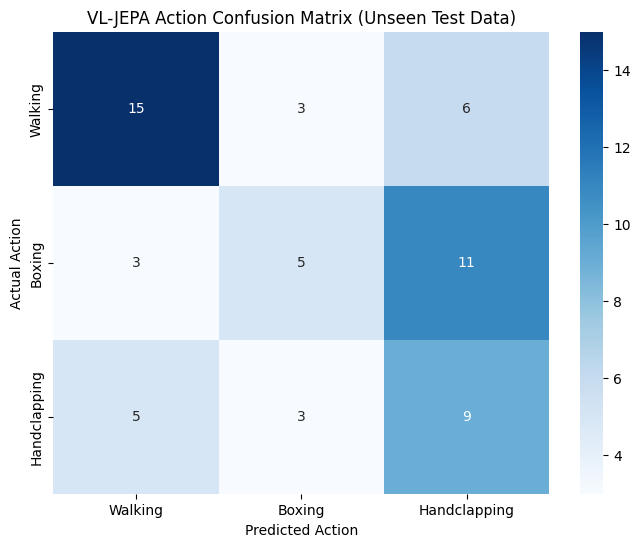

              precision    recall  f1-score   support

     Walking       0.65      0.62      0.64        24
      Boxing       0.45      0.26      0.33        19
Handclapping       0.35      0.53      0.42        17

    accuracy                           0.48        60
   macro avg       0.48      0.47      0.46        60
weighted avg       0.50      0.48      0.48        60



In [47]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def plot_confusion_matrix(model, df_test, num_classes, label_names, text_mapping, feature_col='features'):
    y_true = []
    y_pred = []

    for _, row in df_test.iterrows():
        # Extract features (handling string/list types dynamically)
        val = row[feature_col]
        if isinstance(val, str):
            features = np.array(ast.literal_eval(val))
        else:
            features = np.array(val)
            
        true_label = int(row['target_class'])
        
        # Predict using the 1D features directly (predict function handles reshaping and normalization)
        pred_label = predict(model, features, num_classes, text_mapping)

        y_true.append(true_label)
        y_pred.append(pred_label)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)

    plt.title('VL-JEPA Action Confusion Matrix (Unseen Test Data)')
    plt.ylabel('Actual Action')
    plt.xlabel('Predicted Action')
    plt.show()

    print(classification_report(y_true, y_pred, target_names=label_names))

# ==========================================
# Execution
# ==========================================
if __name__ == "__main__":
    # Make sure this points to the file you want to evaluate
    df_eval = pd.read_csv(r"C:\Users\subhe\OneDrive\Desktop\VL-JEPA\codes\VL-JEPA-base-CCTV\kth_spatial_motion3.csv")

    # Dynamically grab the correct column name
    feat_col = 'features' if 'features' in df_eval.columns else 'hsv_features'
    
    # --------------------------------------------------------
    # REPLICATE THE MANUAL TRAIN/TEST SPLIT
    # --------------------------------------------------------
    # We MUST use the exact same random_state (42) to ensure the test set 
    # contains the exact same videos that were hidden during training!
    df_shuffled_full = df_eval.sample(frac=1, random_state=42).reset_index(drop=True)
    split_idx = int(len(df_shuffled_full) * 0.8)
    
    # Extract ONLY the unseen 20%
    test_df = df_shuffled_full.iloc[split_idx:].reset_index(drop=True)

    labels = ["Walking", "Boxing", "Handclapping"]

    # We MUST provide the exact same text mapping used during training!
    eval_text_mapping = {
        0: ["a", "person", "walking"],
        1: ["a", "person", "boxing"],
        2: ["a", "person", "clapping"]
    }

    # Run the plot on the TEST dataframe
    print(f"Plotting confusion matrix for {len(test_df)} unseen test samples...")
    plot_confusion_matrix(trained_model, test_df, 3, labels, eval_text_mapping, feature_col=feat_col)

In [22]:
def test_model(model, X_v, num_classes):
    """
    Predicts the class by finding the minimum distance in latent space.
    """
    # 1. Forward pass through Visual Encoder
    Z_v = np.dot(model.W_v, X_v) + model.b_v
    S_v = model.relu(Z_v)
    
    # 2. Predict the target latent representation
    S_y_hat = np.dot(model.W_p, S_v) + model.b_p
    
    # 3. Compare S_y_hat to all possible Class Embeddings
    distances = []
    for i in range(num_classes):
        # Create a dummy one-hot vector for each class
        Y_test = np.zeros((num_classes, 1))
        Y_test[i, 0] = 1.0
        
        # Get the "ideal" latent embedding for this class
        S_y_ideal = np.dot(model.W_y, Y_test) + model.b_y
        
        # Calculate L2 distance (Euclidean)
        dist = np.linalg.norm(S_y_hat - S_y_ideal)
        distances.append(dist)
    
    # The predicted class is the one with the smallest distance
    return np.argmin(distances), distances

In [23]:
def evaluate_accuracy(model, csv_path, num_classes):
    df = pd.read_csv(csv_path)
    df['hsv_features'] = df['hsv_features'].apply(ast.literal_eval)
    
    correct = 0
    total = len(df)
    
    print(f"\n--- Evaluating on {total} frames ---")
    
    for _, row in df.iterrows():
        X_v = np.array(row['hsv_features']).reshape(256, 1)
        actual_class = int(row['target_class'])
        
        predicted_class, _ = test_model(model, X_v, num_classes)
        
        if predicted_class == actual_class:
            correct += 1
            
    accuracy = (correct / total) * 100
    print(f"Accuracy: {accuracy:.2f}% ({correct}/{total})")

# Run evaluation
num_classes = num_found_classes
model = FinalNumPyJEPA(input_dim=256, target_classes=num_classes, embed_dim=64, lr=0.005)
evaluate_accuracy(model, "kth_cctv_features.csv", num_found_classes)

TypeError: FinalNumPyJEPA.__init__() got an unexpected keyword argument 'target_classes'

In [ ]:
import cv2
import numpy as np
import os
import pandas as pd

def get_motion_signature(video_path):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames < 5:
        cap.release()
        return None

    # Jump to the middle of the video where action usually happens
    mid_frame = total_frames // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, mid_frame)
    
    ret, frame1 = cap.read()
    ret, frame2 = cap.read()
    if not ret: 
        cap.release()
        return None

    # Convert to grayscale
    prev_gray = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    curr_gray = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    # Calculate Optical Flow (Farneback method)
    # This detects how every pixel moved from frame 1 to frame 2
    flow = cv2.calcOpticalFlowFarneback(prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    
    # Compute Magnitude (how much movement) and Angle (which direction)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    # Create a 256-dimension Motion Histogram
    hist_mag = np.histogram(mag, bins=128, range=(0, 5))[0]
    hist_ang = np.histogram(ang, bins=128, range=(0, 2*np.pi))[0]
    
    motion_features = np.concatenate([hist_mag, hist_ang]).astype(np.float32)
    
    # Normalize
    norm = np.linalg.norm(motion_features)
    if norm > 0:
        motion_features /= norm

    cap.release()
    return motion_features.tolist()

# Run this for your videos
video_dir = r"C:\Users\Ayushman\VL-JEPA-base-CCTV\kth_videos"
dataset_records = []
label_map = {"walking": 0, "boxing": 1, "handclapping": 2}

print("Extracting Motion Features...")
for filename in os.listdir(video_dir):
    if filename.endswith(".avi"):
        action = filename.split("_")[1]
        if action in label_map:
            features = get_motion_signature(os.path.join(video_dir, filename))
            if features:
                dataset_records.append({
                    "video_file": filename,
                    "target_class": label_map[action],
                    "features": features
                })

df = pd.DataFrame(dataset_records)
df.to_csv("kth_motion_features2.csv", index=False)
print("Done! Use 'kth_motion_features.csv' for training now.")

Extracting Motion Features...
Done! Use 'kth_motion_features.csv' for training now.
